In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Smart-Warehouse-Delay/train.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


In [3]:
test = pd.read_csv('../data/Smart-Warehouse-Delay/test.csv')
test

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TEST_000000,WH_202,SC_10973,61.0,155.0,NaN,0.0000,0.0656,0.1311,0.3047,...,4.88,0.0534,4.93,0.2164,13.5,NaN,96.2,0.0374,0.00,97.74
1,TEST_000001,WH_202,SC_10973,59.0,108.0,NaN,NaN,0.0847,0.0847,0.3047,...,6.69,NaN,NaN,NaN,21.1,15.94,90.5,0.0522,3.03,NaN
2,TEST_000002,WH_202,SC_10973,95.0,200.0,3.35,0.0526,NaN,0.1053,0.3047,...,6.28,0.0534,8.57,0.2292,23.2,16.25,NaN,0.0649,1.36,95.31
3,TEST_000003,WH_202,SC_10973,59.0,166.0,4.20,0.0339,0.0508,0.1017,0.3047,...,7.92,0.0835,NaN,0.2045,NaN,15.57,NaN,0.0268,0.64,94.01
4,TEST_000004,WH_202,SC_10973,NaN,130.0,NaN,0.0200,0.0200,0.1000,0.3047,...,7.00,0.1684,NaN,0.2174,NaN,17.16,91.0,0.0533,0.25,95.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TEST_049995,WH_225,SC_10910,13.0,9.0,1.31,0.0000,0.0000,0.0000,NaN,...,4.59,0.2267,8.26,0.0450,18.3,NaN,84.8,NaN,NaN,95.08
49996,TEST_049996,WH_225,SC_10910,NaN,NaN,1.00,0.0000,0.3333,0.0000,0.2150,...,4.80,0.1775,6.18,0.0305,9.6,9.82,83.0,0.1309,9.64,94.56
49997,TEST_049997,WH_225,SC_10910,10.0,NaN,2.10,NaN,0.0000,0.0000,0.2150,...,5.71,0.2488,6.52,0.0536,9.4,NaN,86.9,0.1206,9.75,96.14
49998,TEST_049998,WH_225,SC_10910,17.0,15.0,NaN,NaN,0.2353,0.0000,0.2150,...,5.15,NaN,9.41,0.0881,20.1,12.96,81.9,0.1228,8.09,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 94 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          250000 non-null  object 
 1   layout_id                   250000 non-null  object 
 2   scenario_id                 250000 non-null  object 
 3   order_inflow_15m            220436 non-null  float64
 4   unique_sku_15m              220076 non-null  float64
 5   avg_items_per_order         220377 non-null  float64
 6   urgent_order_ratio          220246 non-null  float64
 7   heavy_item_ratio            220384 non-null  float64
 8   cold_chain_ratio            220549 non-null  float64
 9   sku_concentration           220301 non-null  float64
 10  robot_active                250000 non-null  int64  
 11  robot_idle                  250000 non-null  int64  
 12  robot_charging              250000 non-null  int64  
 13  robot_utilizat

##### 
타깃 결측치 확인

In [5]:
int(df['avg_delay_minutes_next_30m'].isnull().sum())

0

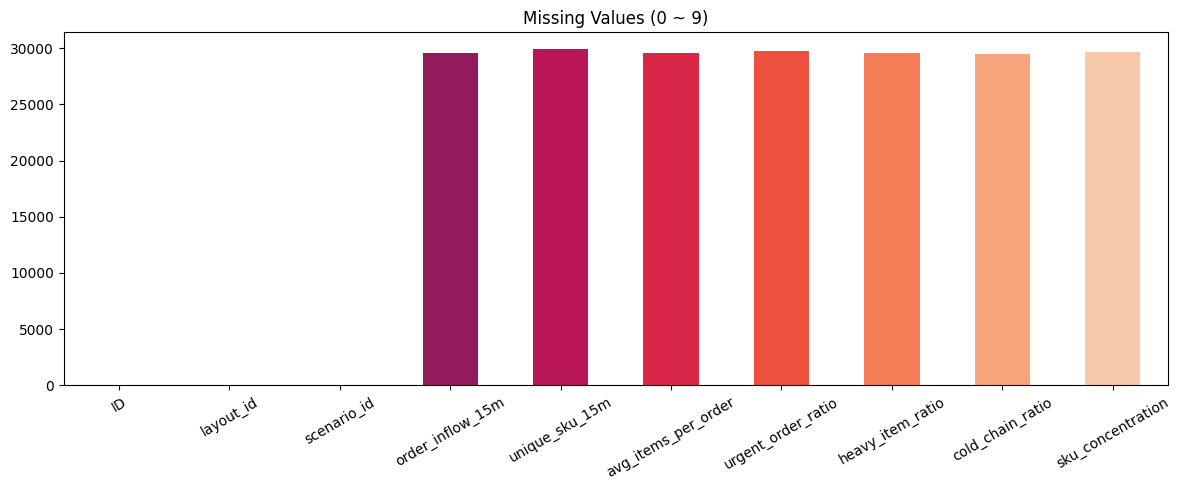

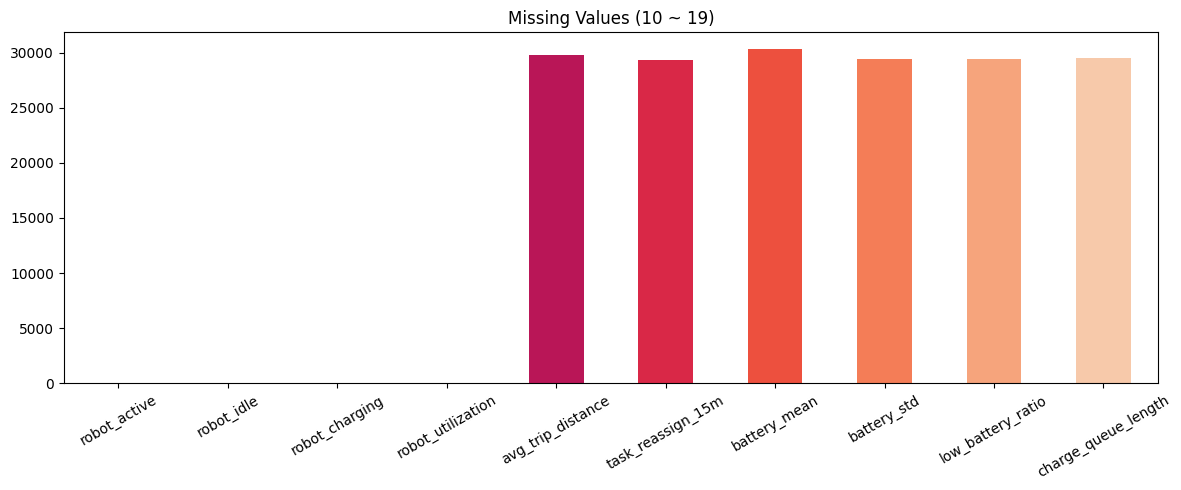

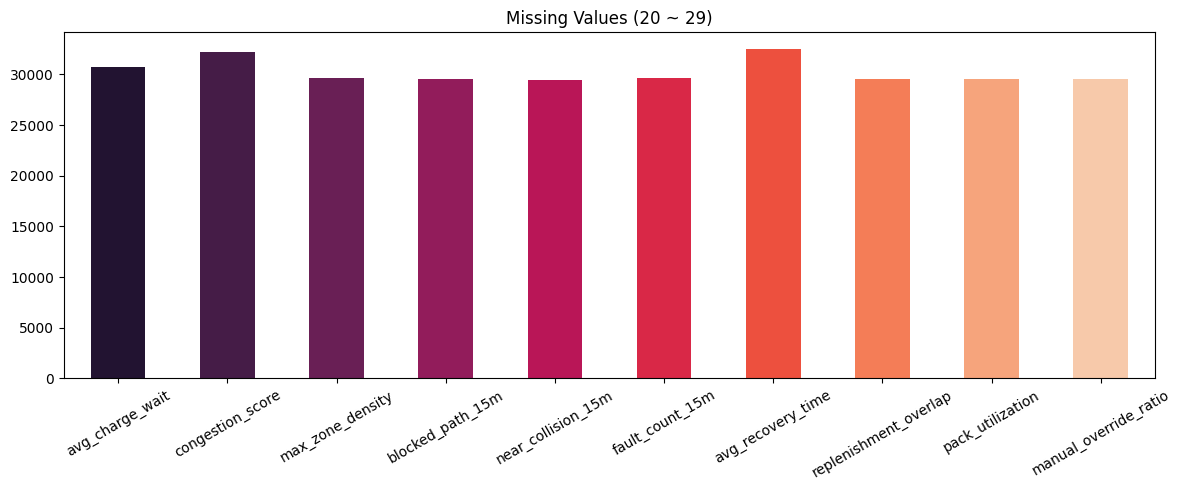

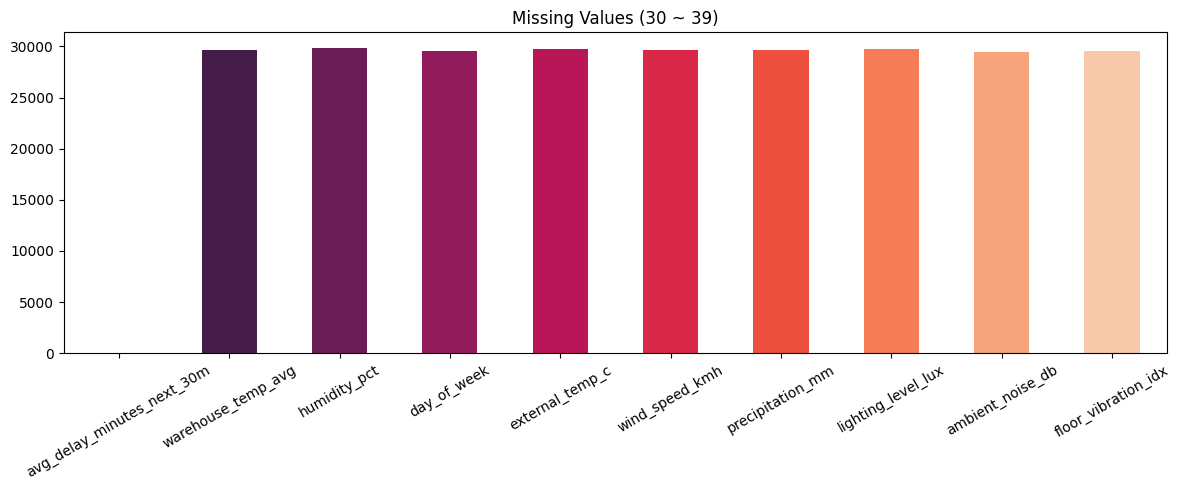

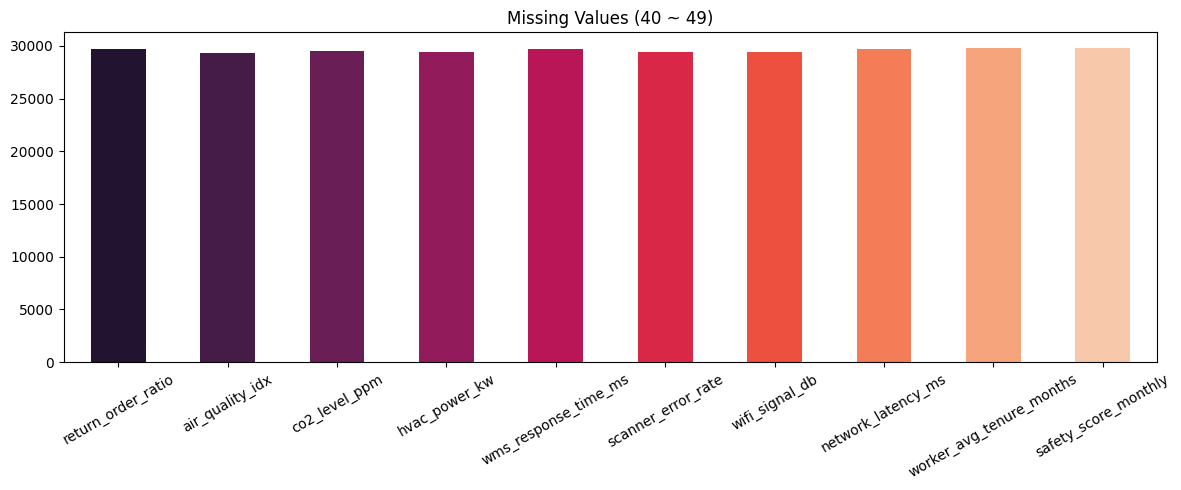

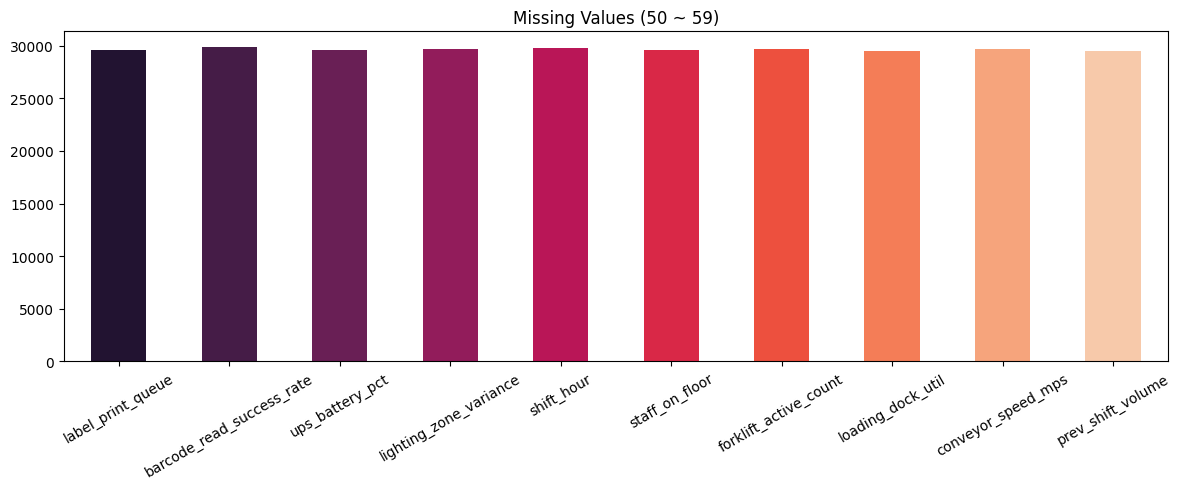

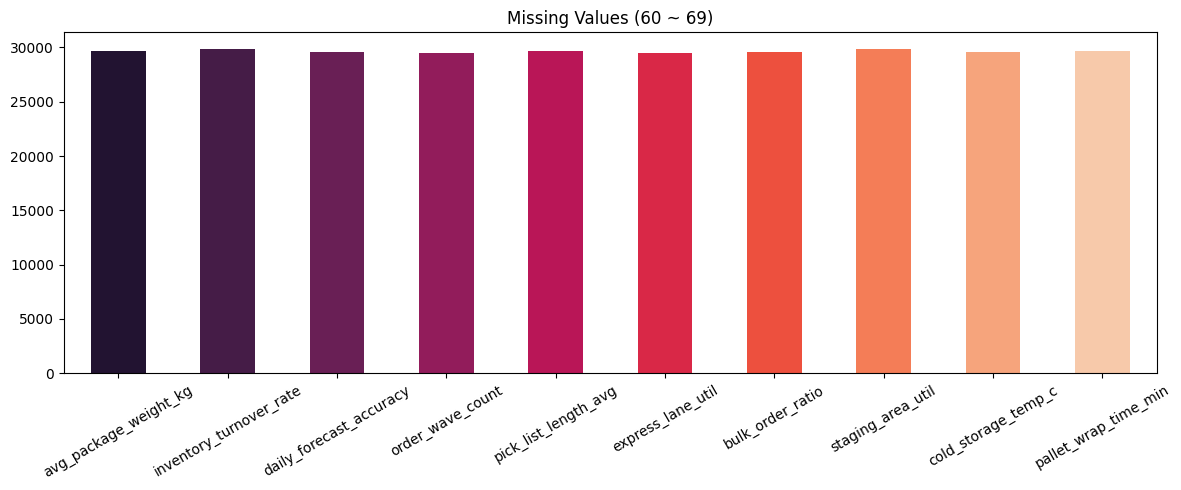

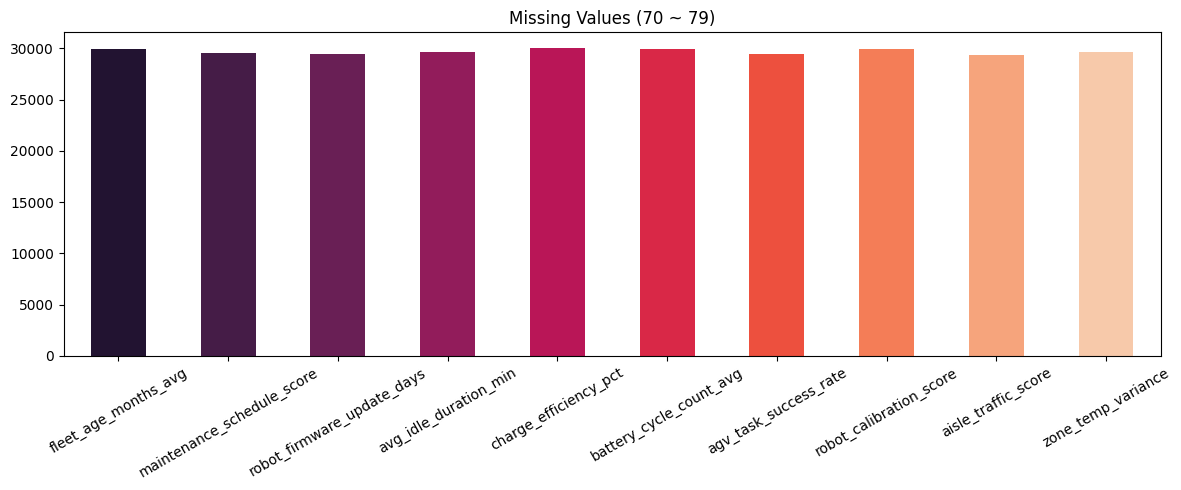

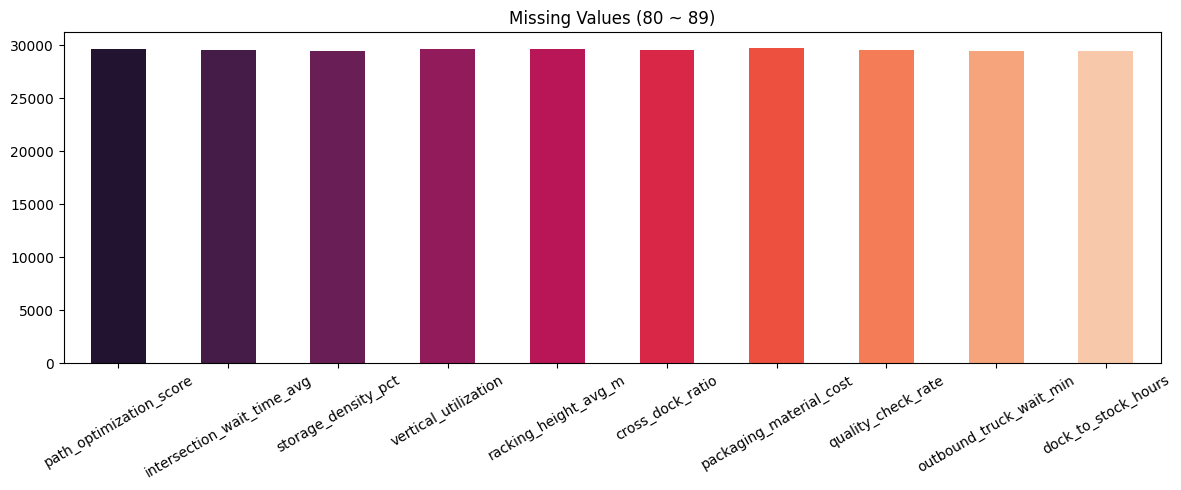

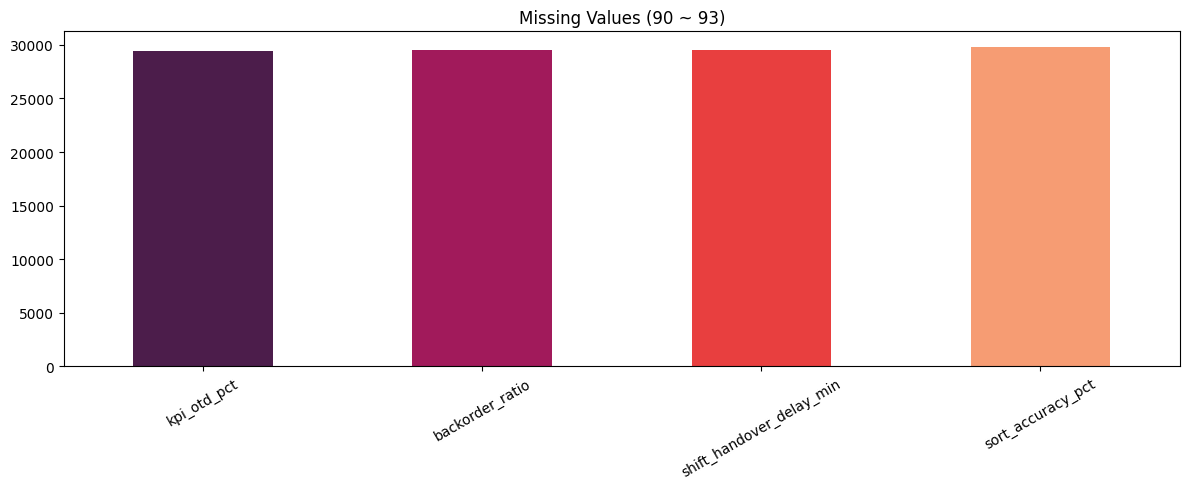

In [6]:
missing = df.isnull().sum()

cols = missing.index
n = len(cols)
chunk_size = 10

for i in range(0, n, chunk_size):
    subset = missing.iloc[i:i+chunk_size]

    colors = sns.color_palette("rocket", len(subset))
    
    plt.figure(figsize=(12, 5))
    subset.plot(kind='bar', color=colors)
    
    plt.title(f'Missing Values ({i} ~ {i+len(subset)-1})')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### **📦 1. 주문 / 수요 관련**
* order_inflow_15m → 15분 동안 들어온 주문 수
* unique_sku_15m → 15분 동안 등장한 SKU 종류 수
* avg_items_per_order → 주문당 평균 상품 개수
* urgent_order_ratio → 긴급 주문 비율
* bulk_order_ratio → 대량 주문 비율
* order_wave_count → 주문 묶음(웨이브) 개수
* pick_list_length_avg → 평균 피킹 리스트 길이
* express_lane_util → 빠른 처리 라인 사용률 👉 주문량 + 복잡도 = 지연의 핵심 원인

### **🤖 2. 로봇 / AGV 상태**
* robot_active → 작업 중인 로봇 수
* robot_idle → 대기 중인 로봇 수
* robot_charging → 충전 중인 로봇 수
* robot_utilization → 로봇 활용률
* avg_idle_duration_min → 평균 유휴 시간(분)
* agv_task_success_rate → AGV 작업 성공률
* robot_calibration_score → 로봇 보정 상태 점수

### **🔋 3. 배터리 & 충전**
* battery_mean → 평균 배터리 잔량
* battery_std → 배터리 잔량 편차
* low_battery_ratio → 배터리 부족 로봇 비율
* charge_queue_length → 충전 대기 줄 길이
* avg_charge_wait → 평균 충전 대기 시간
* charge_efficiency_pct → 충전 효율
* battery_cycle_count_avg → 평균 충전 사이클 수

### **🚧 4. 혼잡 / 경로 / 충돌**
* congestion_score → 창고 혼잡도 점수
* max_zone_density → 특정 구역 최대 밀집도
* blocked_path_15m → 막힌 경로 수 (15분)
* near_collision_15m → 충돌 직전 이벤트 수
* aisle_traffic_score → 통로 교통량 점수
* intersection_wait_time_avg → 교차로 평균 대기 시간
* path_optimization_score → 경로 최적화 점수 👉 이 그룹 = 출고 지연 핵심

### **🛠️ 5. 장애 / 유지보수**
* fault_count_15m → 장애 발생 횟수
* avg_recovery_time → 평균 복구 시간
* maintenance_schedule_score → 유지보수 계획 점수
* robot_firmware_update_days → 펌웨어 업데이트 후 경과일
* fleet_age_months_avg → 로봇 평균 사용 기간

### **📦 6. 창고 작업 효율**
* pack_utilization → 포장 작업 활용률
* replenishment_overlap → 보충 작업 겹침 정도
* manual_override_ratio → 수동 개입 비율
* staging_area_util → 적치 공간 활용률
* loading_dock_util → 도크 사용률
* conveyor_speed_mps → 컨베이어 속도
* pallet_wrap_time_min → 팔레트 포장 시간

### **👷 7. 인력 관련**
* staff_on_floor → 현장 작업자 수
* worker_avg_tenure_months → 평균 근속 기간
* shift_hour → 근무 시간대
* shift_handover_delay_min → 교대 지연 시간

### **🌡️ 8. 창고 내부 환경**
* warehouse_temp_avg → 창고 평균 온도
* humidity_pct → 습도
* lighting_level_lux → 조도
* ambient_noise_db → 소음 수준
* floor_vibration_idx → 바닥 진동 지수
* air_quality_idx → 공기질 지수
* co2_level_ppm → 이산화탄소 농도

### **🌦️ 9. 외부 환경**
* external_temp_c → 외부 온도
* wind_speed_kmh → 풍속
* precipitation_mm → 강수량

### **💻 10. IT / 시스템 성능**
* wms_response_time_ms → WMS 응답 시간
* scanner_error_rate → 스캐너 오류율
* wifi_signal_db → 와이파이 신호 강도
* network_latency_ms → 네트워크 지연
* barcode_read_success_rate → 바코드 인식 성공률
* label_print_queue → 라벨 출력 대기 수

### **📊 11. 운영 KPI / 성과**
* kpi_otd_pct → 정시 출고율 (On-time delivery)
* backorder_ratio → 백오더 비율
* outbound_truck_wait_min → 출고 트럭 대기 시간
* dock_to_stock_hours → 입고→재고 반영 시간
* inventory_turnover_rate → 재고 회전율
* daily_forecast_accuracy → 수요 예측 정확도

### **📦 12. 상품 특성**
* heavy_item_ratio → 무거운 상품 비율
* cold_chain_ratio → 냉장/냉동 상품 비율
* avg_package_weight_kg → 평균 패키지 무게
* sku_concentration → SKU 집중도
* return_order_ratio → 반품 비율

### **🏗️ 13. 창고 구조 / 공간**
* storage_density_pct → 저장 밀도
* vertical_utilization → 수직 공간 활용률
* racking_height_avg_m → 평균 랙 높이
* cross_dock_ratio → 크로스도킹 비율

In [7]:
col_groups = {
    "order": [
        "order_inflow_15m","unique_sku_15m","avg_items_per_order",
        "urgent_order_ratio","bulk_order_ratio","order_wave_count",
        "pick_list_length_avg","express_lane_util"
    ],
    
    "robot": [
        "robot_active","robot_idle","robot_charging","robot_utilization",
        "avg_idle_duration_min","agv_task_success_rate","robot_calibration_score"
    ],
    
    "battery": [
        "battery_mean","battery_std","low_battery_ratio",
        "charge_queue_length","avg_charge_wait",
        "charge_efficiency_pct","battery_cycle_count_avg"
    ],
    
    "traffic": [
        "congestion_score","max_zone_density","blocked_path_15m",
        "near_collision_15m","aisle_traffic_score",
        "intersection_wait_time_avg","path_optimization_score"
    ],
    
    "fault": [
        "fault_count_15m","avg_recovery_time","maintenance_schedule_score",
        "robot_firmware_update_days","fleet_age_months_avg"
    ],
    
    "operation": [
        "pack_utilization","replenishment_overlap","manual_override_ratio",
        "staging_area_util","loading_dock_util",
        "conveyor_speed_mps","pallet_wrap_time_min"
    ],
    
    "staff": [
        "staff_on_floor","worker_avg_tenure_months",
        "shift_hour","shift_handover_delay_min"
    ],
    
    "env_internal": [
        "warehouse_temp_avg","humidity_pct","lighting_level_lux",
        "ambient_noise_db","floor_vibration_idx",
        "air_quality_idx","co2_level_ppm"
    ],
    
    "env_external": [
        "external_temp_c","wind_speed_kmh","precipitation_mm"
    ],
    
    "it_system": [
        "wms_response_time_ms","scanner_error_rate","wifi_signal_db",
        "network_latency_ms","barcode_read_success_rate","label_print_queue"
    ],
    
    "kpi": [
        "kpi_otd_pct","backorder_ratio","outbound_truck_wait_min",
        "dock_to_stock_hours","inventory_turnover_rate",
        "daily_forecast_accuracy"
    ],
    
    "product": [
        "heavy_item_ratio","cold_chain_ratio","avg_package_weight_kg",
        "sku_concentration","return_order_ratio"
    ],
    
    "space": [
        "storage_density_pct","vertical_utilization",
        "racking_height_avg_m","cross_dock_ratio"
    ]
}

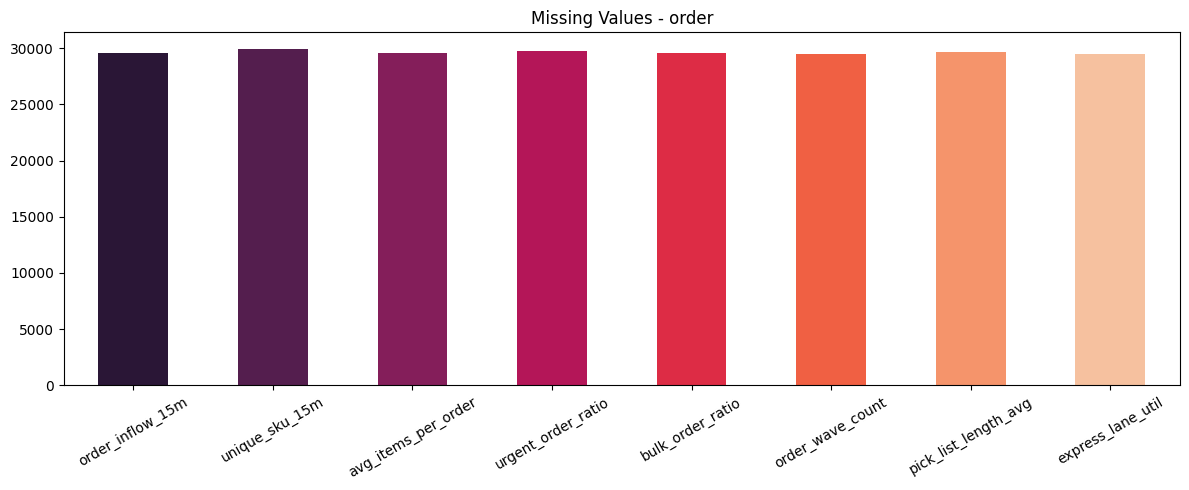

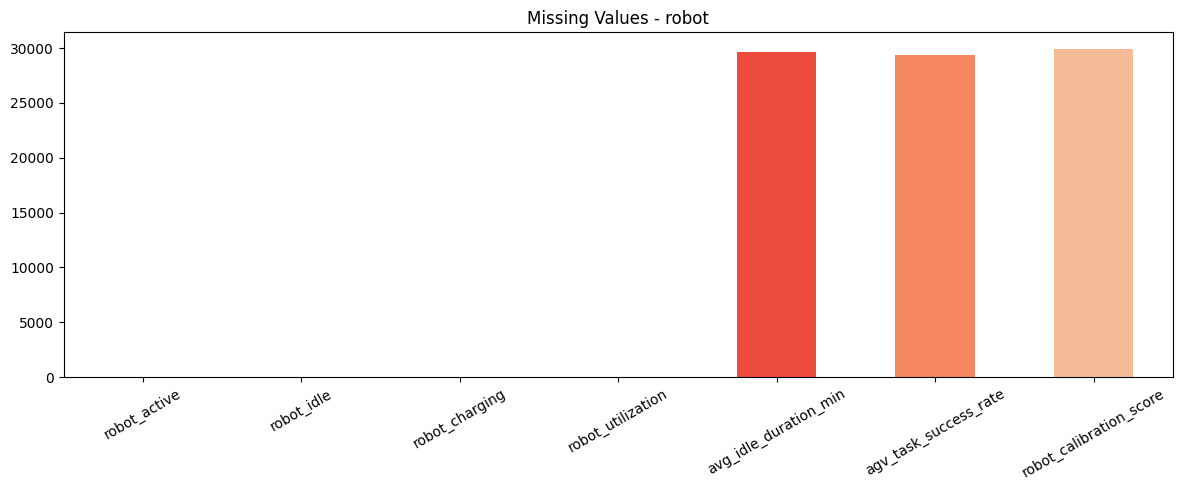

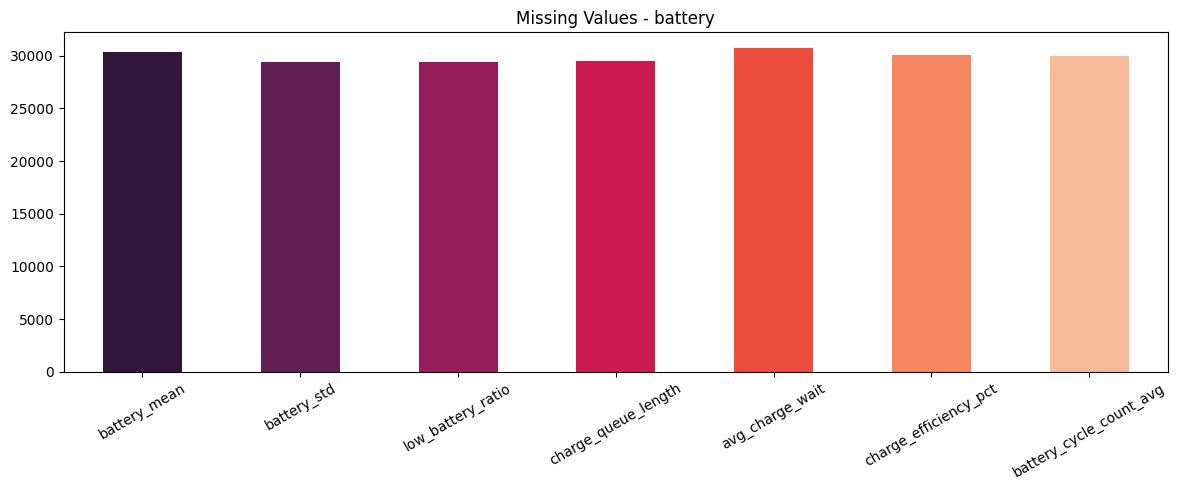

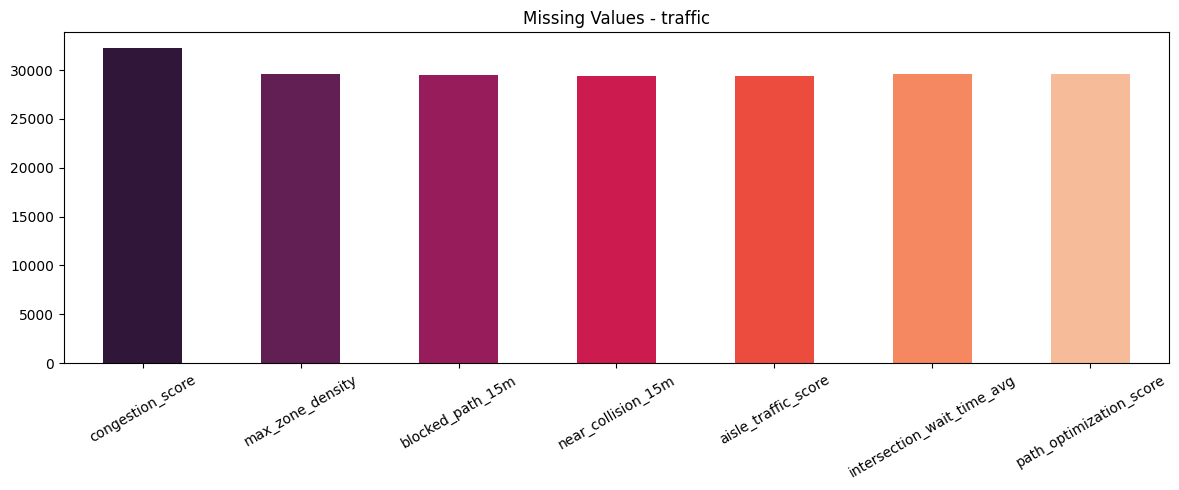

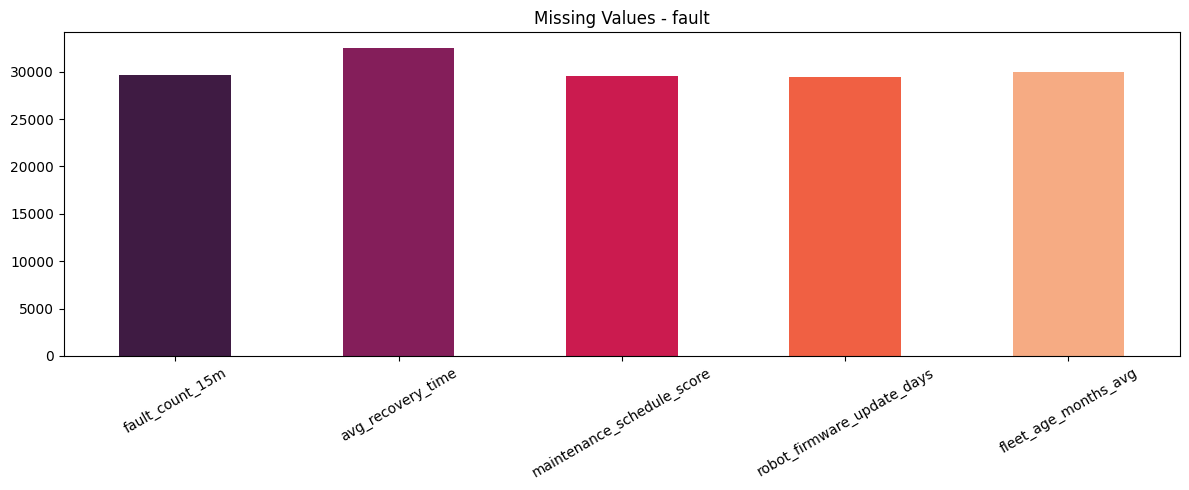

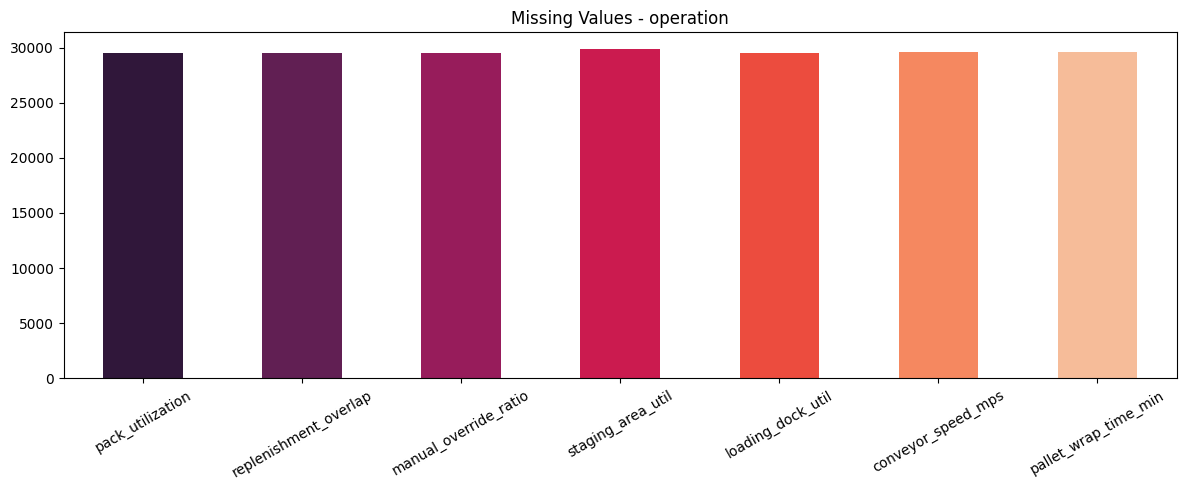

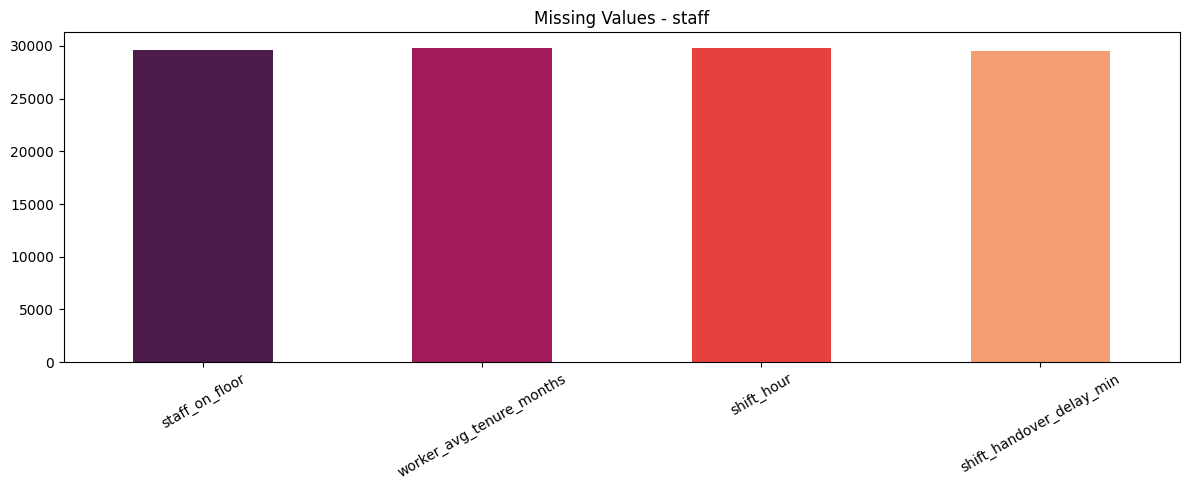

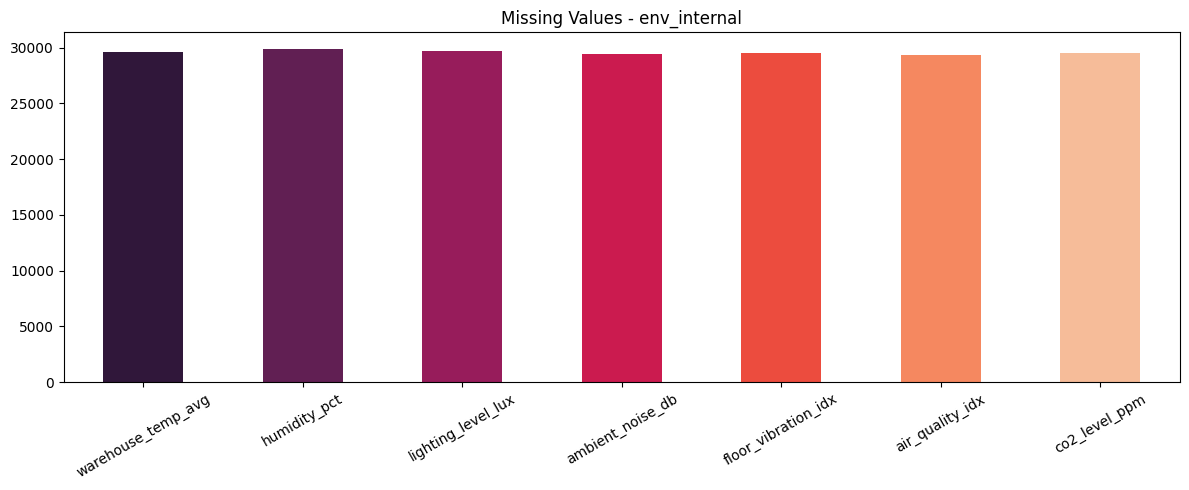

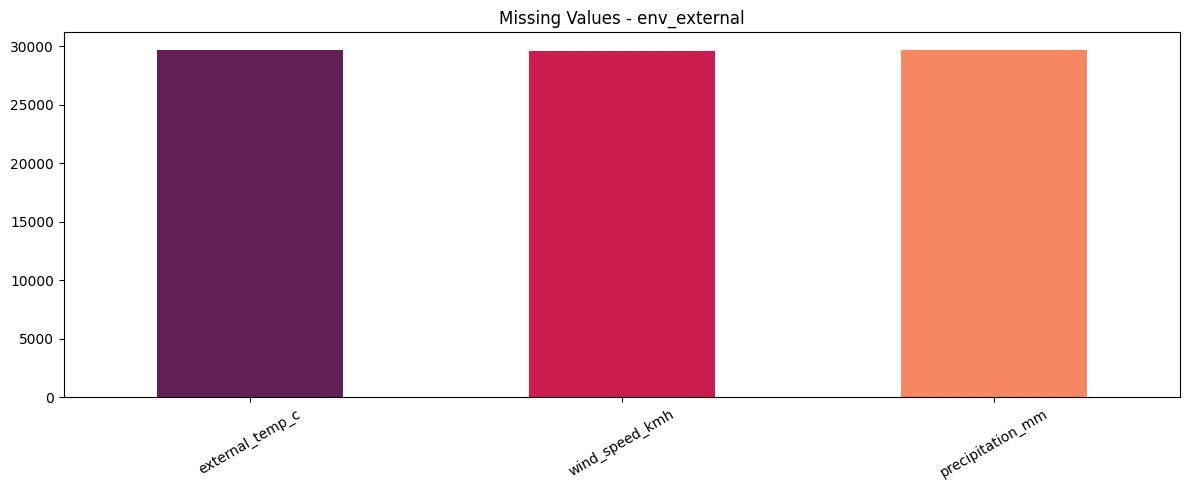

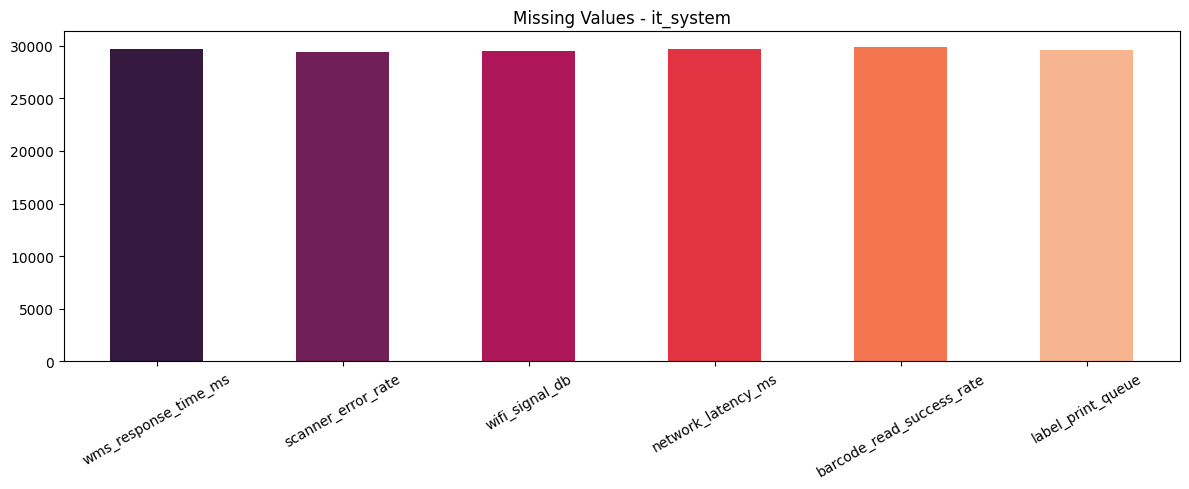

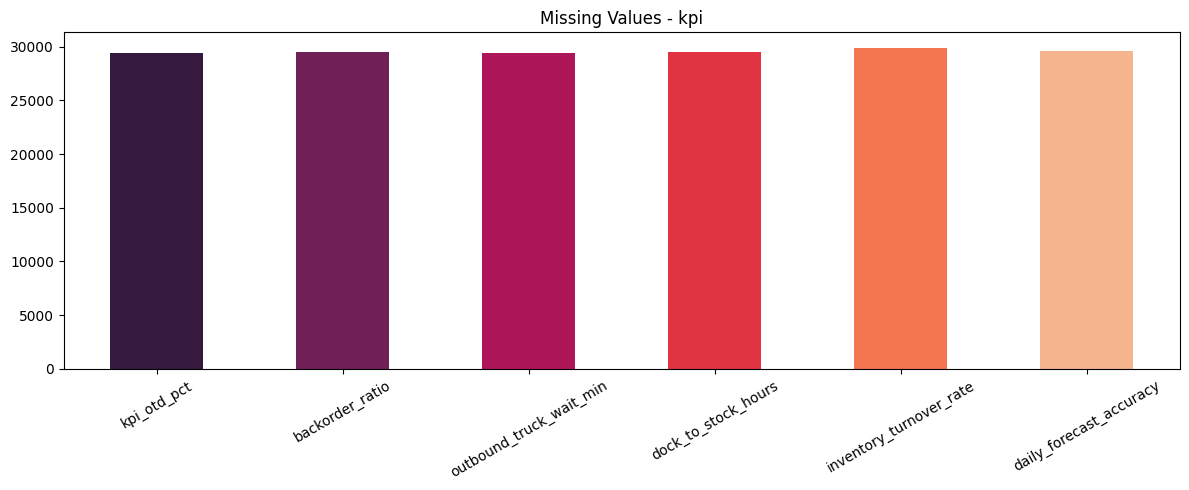

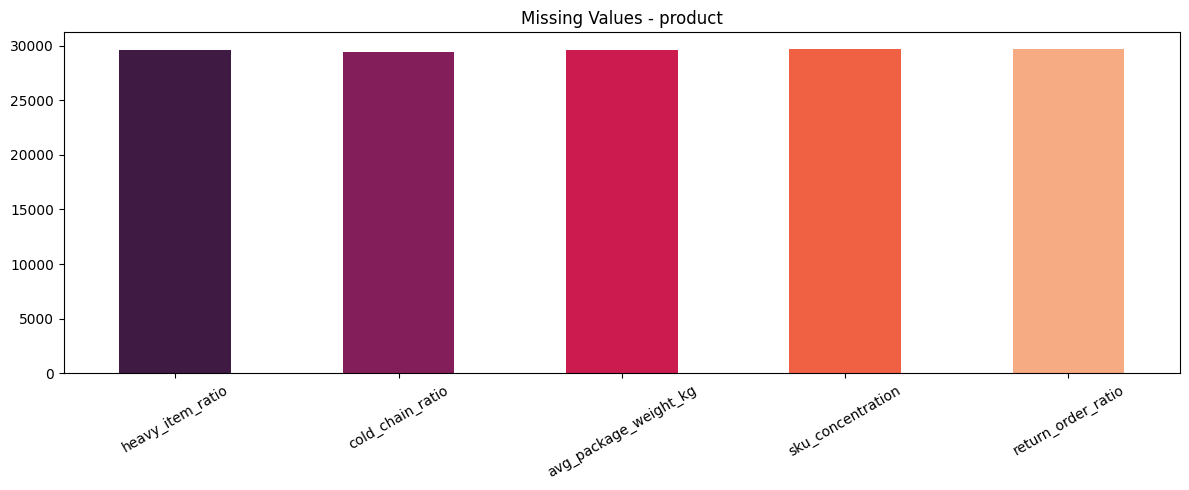

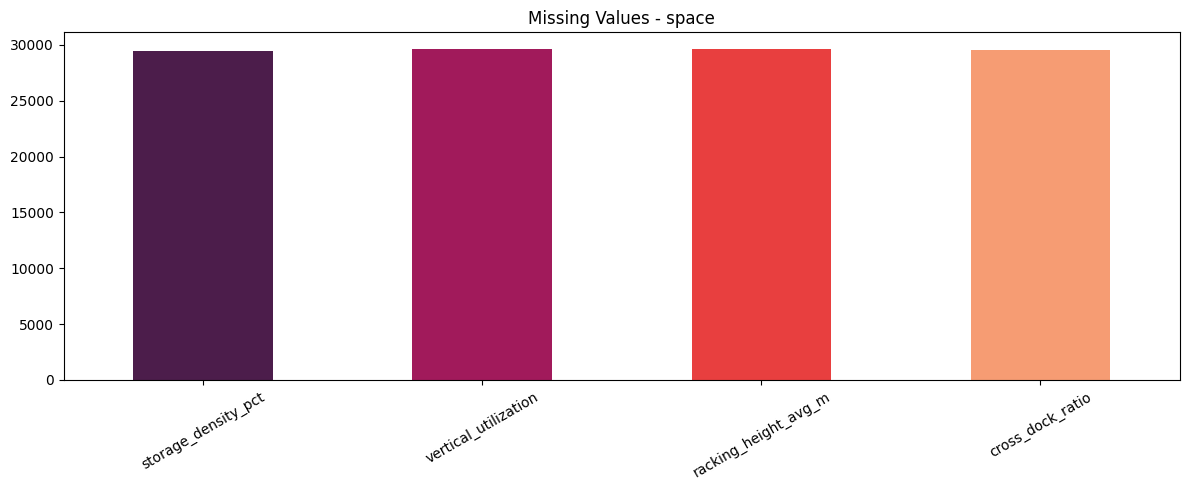

In [8]:
missing = df.isnull().sum()

for group_name, col_list in col_groups.items():
    # df에 실제 존재하는 컬럼만 필터 (혹시 없는 컬럼 대비)
    valid_cols = [col for col in col_list if col in missing.index]
    
    if len(valid_cols) == 0:
        continue
    
    subset = missing[valid_cols]
    colors = sns.color_palette("rocket", len(subset))
    
    plt.figure(figsize=(12, 5))
    subset.plot(kind='bar', color=colors)
    
    plt.title(f'Missing Values - {group_name}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()